In [22]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
from IPython.display import HTML
import os
import matplotlib.pyplot as plt
import plotly.express as px

class BatchProcessingMachine:
    def __init__(self, processing_time, batch_size):
        self.processing_time = processing_time
        self.batch_size = batch_size
        self.current_product = None
        self.finish_time = 0
        self.busy = False
        self.event_log = []

    def process(self, product, current_time):
        self.busy = True
        self.finish_time = current_time + self.processing_time
        self.current_product = product
        self.event_log.append((self.current_product, current_time, self.finish_time, self.batch_size))
        return self.finish_time

    def update(self, current_time):
        if current_time >= self.finish_time and self.busy:
            self.busy = False
            return self.current_product
        return False
    
    def print_event_log(self, machine_name):
        for event in self.event_log:
            print(f"At machine {machine_name}: Batch of Product {event[0]} processed from {event[1]} to {event[2]}")

In [23]:
class Machine:
    def __init__(self, processing_times, setup_times):
        self.processing_times = processing_times
        self.setup_times = setup_times
        self.current_product = None
        self.finish_time = 0
        self.busy = False
        self.event_log = []

    def process(self, product, current_time):
        if self.current_product is not None:
            setup_time = self.setup_times[self.current_product][product]
        else:
            setup_time = self.setup_times[None][product]  # Use the setup time from 'None' to the new product
        self.current_product = product
        start_time = current_time + setup_time
        self.finish_time = start_time + self.processing_times[product]
        self.busy = True
        self.event_log.append((product, current_time, start_time, self.finish_time))
        return self.finish_time

    def update(self, current_time):
        if current_time >= self.finish_time and self.busy:
            self.busy = False
            return self.current_product
        return None

    def print_event_log(self, machine_name):
        for event in self.event_log:
            print(f"At machine {machine_name}: Product {event[0]} processed from {event[1]} to {event[3]}")

In [30]:
class ProductionLine:
    def __init__(self, batch_machine0_time, machine1_times, machine1_setups, batch_machine2_time, machine3_times, machine3_setups, arrival_rate1, arrival_rate2):
        self.machine0 = BatchProcessingMachine(batch_machine0_time, 4)
        self.machine1 = Machine(machine1_times, machine1_setups)
        self.machine2 = BatchProcessingMachine(batch_machine2_time, 4)
        self.machine3 = Machine(machine3_times, machine3_setups)
        self.arrival_rate1 = arrival_rate1
        self.arrival_rate2 = arrival_rate2
        self.next_arrival1 = 0
        self.next_arrival2 = 0
        self.queues = {'queue0': [[], []], 'queue1': [[], []], 'queue2': [[], []], 'queue3': [[], []],'queue_fin': [[], []]}
        self.logs = {key: [] for key in self.queues}  # Initialize logs for each queue

    def add_item_to_queue(self, queue_name, product, current_time):
        self.queues[queue_name][product].append(current_time)
        queue_sizes = [len(q) for q in self.queues[queue_name]]
        self.logs[queue_name].append((queue_sizes, current_time))

    def run_step(self, current_time):
        # Handle product arrivals
        for product, next_arrival in zip([0, 1], [self.next_arrival1, self.next_arrival2]):
            if current_time >= next_arrival:
                self.add_item_to_queue('queue0', product, current_time)
                if product == 0:
                    self.next_arrival1 += self.arrival_rate1
                else:
                    self.next_arrival2 += self.arrival_rate2

        # Process batches in Machine 0
        for product_type in range(2):
            if current_time >= self.machine0.finish_time and self.machine0.busy:
                finished_product = self.machine0.update(current_time)
                # Transfer the whole batch to the next queue
                for i in range(self.machine0.batch_size):
                    self.add_item_to_queue('queue1', finished_product, current_time)
            while len(self.queues['queue0'][product_type]) >= self.machine0.batch_size and not self.machine0.busy:
                # Batch is full and machine is not busy
                finish_time = self.machine0.process(product_type,current_time)  # Process batch
                self.queues['queue0'][product_type] = self.queues['queue0'][product_type][self.machine0.batch_size:]

        # Process products at Machine 1
        for product_type in range(2):
            if current_time >= self.machine1.finish_time and self.machine1.busy:
                finished_product1 = self.machine1.update(current_time)
                if finished_product1 is not None:  # Move to next queue if not the last machine
                    self.add_item_to_queue('queue2', finished_product1, current_time)
            if self.queues['queue1'][product_type] and not self.machine1.busy:
                product_time = self.queues['queue1'][product_type].pop(0)
                self.machine1.process(product_type, current_time)

        # Process batches in Machine 2
        for product_type in range(2):
            while len(self.queues['queue2'][product_type]) >= self.machine2.batch_size and not self.machine2.busy:
                # Batch is full and machine is not busy
                finish_time = self.machine2.process(product_type,current_time)  # Process batch
                self.queues['queue2'][product_type] = self.queues['queue2'][product_type][self.machine2.batch_size:]
            if current_time >= self.machine2.finish_time and self.machine2.busy:
                finished_product2 = self.machine2.update(current_time)
                # Transfer the whole batch to the next queue
                for i in range(self.machine2.batch_size):
                    self.add_item_to_queue('queue3', finished_product2, current_time)

        # Process products at Machine 3
        for product_type in range(2):
            if self.queues['queue3'][product_type] and not self.machine3.busy:
                product_time = self.queues['queue3'][product_type].pop(0)
                self.machine3.process(product_type, current_time)
            if current_time >= self.machine3.finish_time and self.machine3.busy:
                finished_product3 = self.machine3.update(current_time)
                if finished_product3 is not None:  # Move to next queue if not the last machine
                    self.add_item_to_queue('queue_fin', finished_product3, current_time)


    def print_logs(self):
        # Printing logs for all queues
        for key in self.queues:
            print(f"{key} Event Log:")
            for log in self.logs[key]:
                print(f"Time {log[1]}: Queue Sizes - Product 0: {log[0][0]}, Product 1: {log[0][1]}")

        # Print machine logs
        print("\nMachine Logs:")
        machine_names = ['Machine 0', 'Machine 1', 'Machine 2', 'Machine 3']
        for i in range(4):
            machine = getattr(self, f'machine{i}')
            machine.print_event_log(machine_names[i])

# Example simulation setup
production_line = ProductionLine(10, {0: 3, 1: 4}, {None: {0: 5, 1: 3}, 0: {0: 0, 1: 10}, 1: {0: 5, 1: 0}}, 10,
                                 {0: 10, 1: 12}, {None: {0: 0, 1: 0}, 0: {0: 0, 1: 2}, 1: {0: 3, 1: 0}}, 5, 10)

for current_time in range(200):
    production_line.run_step(current_time)

production_line.print_logs()

queue0 Event Log:
Time 0: Queue Sizes - Product 0: 1, Product 1: 0
Time 0: Queue Sizes - Product 0: 1, Product 1: 1
Time 5: Queue Sizes - Product 0: 2, Product 1: 1
Time 10: Queue Sizes - Product 0: 3, Product 1: 1
Time 10: Queue Sizes - Product 0: 3, Product 1: 2
Time 15: Queue Sizes - Product 0: 4, Product 1: 2
Time 20: Queue Sizes - Product 0: 1, Product 1: 2
Time 20: Queue Sizes - Product 0: 1, Product 1: 3
Time 25: Queue Sizes - Product 0: 2, Product 1: 3
Time 30: Queue Sizes - Product 0: 3, Product 1: 3
Time 30: Queue Sizes - Product 0: 3, Product 1: 4
Time 35: Queue Sizes - Product 0: 4, Product 1: 0
Time 40: Queue Sizes - Product 0: 5, Product 1: 0
Time 40: Queue Sizes - Product 0: 5, Product 1: 1
Time 45: Queue Sizes - Product 0: 2, Product 1: 1
Time 50: Queue Sizes - Product 0: 3, Product 1: 1
Time 50: Queue Sizes - Product 0: 3, Product 1: 2
Time 55: Queue Sizes - Product 0: 4, Product 1: 2
Time 60: Queue Sizes - Product 0: 1, Product 1: 2
Time 60: Queue Sizes - Product 0: 1

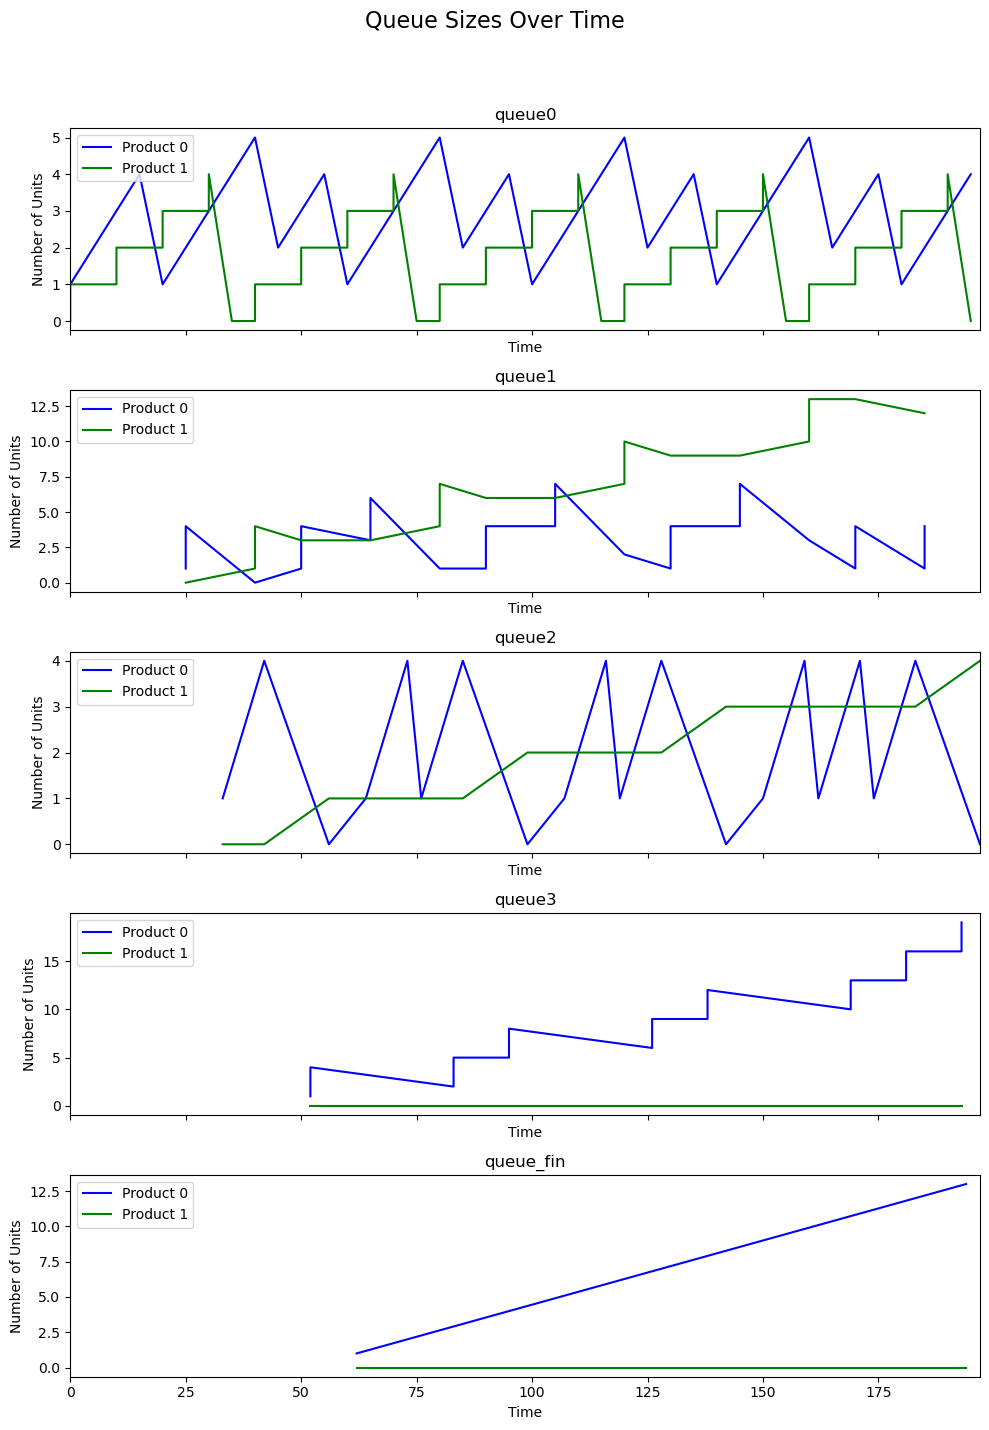

In [31]:
import matplotlib.pyplot as plt

# Plotting queue sizes including 'queue_fin'
fig, axes = plt.subplots(5, 1, figsize=(10, 15), sharex=True)  # Share x-axis across all subplots and increase to 5 subplots
fig.suptitle('Queue Sizes Over Time', fontsize=16)

queue_names = ['queue0', 'queue1', 'queue2', 'queue3', 'queue_fin']
colors = ['blue', 'green']
labels = ['Product 0', 'Product 1']

# Determine the global minimum and maximum time across all queues for consistent x-axis
all_times = [log[1] for queue in queue_names for log in production_line.logs[queue]]
global_min_time = min(all_times)
global_max_time = max(all_times)

for i, ax in enumerate(axes):
    for product_type in range(2):
        times = [log[1] for log in production_line.logs[queue_names[i]]]
        sizes = [log[0][product_type] for log in production_line.logs[queue_names[i]]]
        ax.plot(times, sizes, color=colors[product_type], label=f'Product {product_type}')
    ax.set_title(f'{queue_names[i]}')
    ax.set_xlim([global_min_time, global_max_time])  # Set consistent x-axis range
    ax.set_xlabel('Time')
    ax.set_ylabel('Number of Units')
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

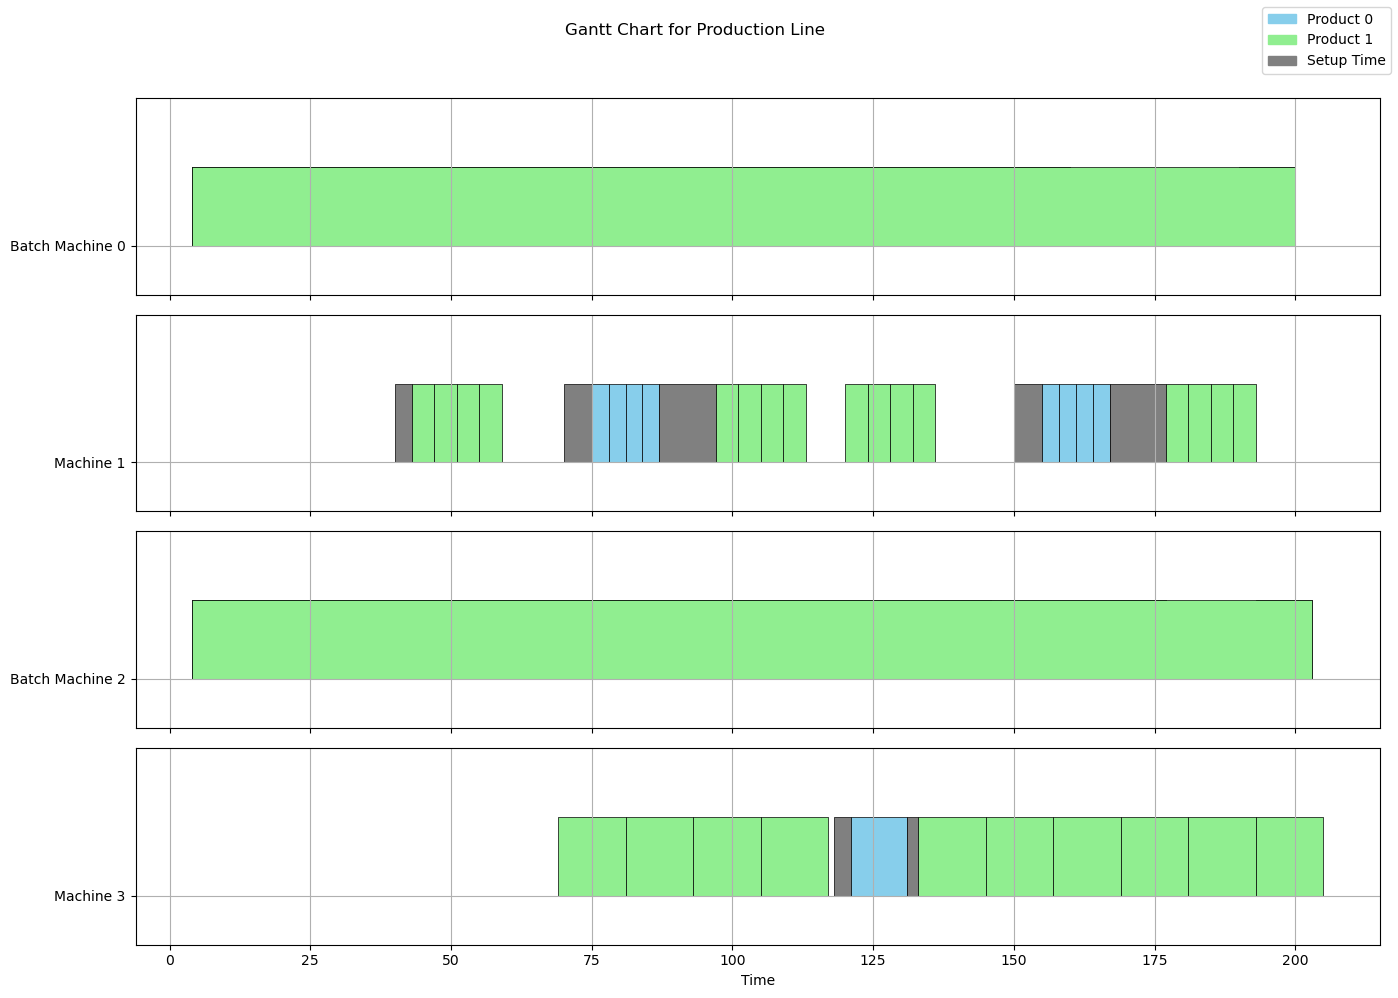

In [25]:
# Setup for Gantt chart plotting using matplotlib
fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Gantt Chart for Production Line')

# Color coding for products and setups
colors = {0: 'skyblue', 1: 'lightgreen', 'setup': 'grey'}

machines = ['machine0', 'machine1', 'machine2', 'machine3']
machine_names = ['Batch Machine 0', 'Machine 1', 'Batch Machine 2', 'Machine 3']

# Plot each machine's activities
for ax, machine_name, name in zip(axs, machines, machine_names):
    machine = getattr(production_line, machine_name)
    y = 0
    for log in machine.event_log:
        if len(log) == 4:  # BatchProcessingMachine or Machine with setup
            product, current_time, start_time, finish_time = log
            # Calculate setup time and process time
            setup_time = start_time - current_time
            process_time = finish_time - start_time
            # Plot setup time if exists
            if setup_time > 0:
                ax.broken_barh([(current_time, setup_time)], (y, 0.8), facecolors='grey', edgecolor='black', linewidth=0.5)
            # Plot process time
            ax.broken_barh([(start_time, process_time)], (y, 0.8), facecolors=colors[product], edgecolor='black', linewidth=0.5)
        else:  # For single product processing without batch
            product, current_time, finish_time, _ = log
            process_time = finish_time - current_time
            ax.broken_barh([(current_time, process_time)], (y, 0.8), facecolors=colors[product], edgecolor='black', linewidth=0.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_yticks([0])
    ax.set_yticklabels([name])
    ax.grid(True)

# Create legend for product colors
patches = [mpatches.Patch(color=colors[key], label=f'Product {key}' if key != 'setup' else 'Setup Time') for key in colors]
fig.legend(handles=patches, loc='upper right')

plt.xlabel('Time')
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make room for title
plt.show()

In [ ]:
#Next steps
# 1) Introduce a demand forecast into the state space and reward it for meeting future excess demand
# 2) See if it can switch demand patterns quickly 
# 3) Q-learning implementaion to achive the same result
# 4) Write a LP program of this